In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

# Step 1: Generate synthetic data
np.random.seed(42)
n_samples = 300
X = np.random.rand(n_samples, 1)
y = 3 * X**3 - 2 * X**2 + X + np.random.randn(n_samples, 1)

In [2]:
# Step 2: Define inner and outer CV
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Step 3: Define variables
deg_range = range(1, 21)
test_mse_outer = []
best_degs = []
fits_over_folds = []
X_grid = np.linspace(0, 1, 200).reshape(-1, 1)

Best degree = 5, Test MSE = 0.6923
Best degree = 3, Test MSE = 1.1884
Best degree = 7, Test MSE = 1.1600
Best degree = 10, Test MSE = 0.9380


Best degree = 4, Test MSE = 1.0106


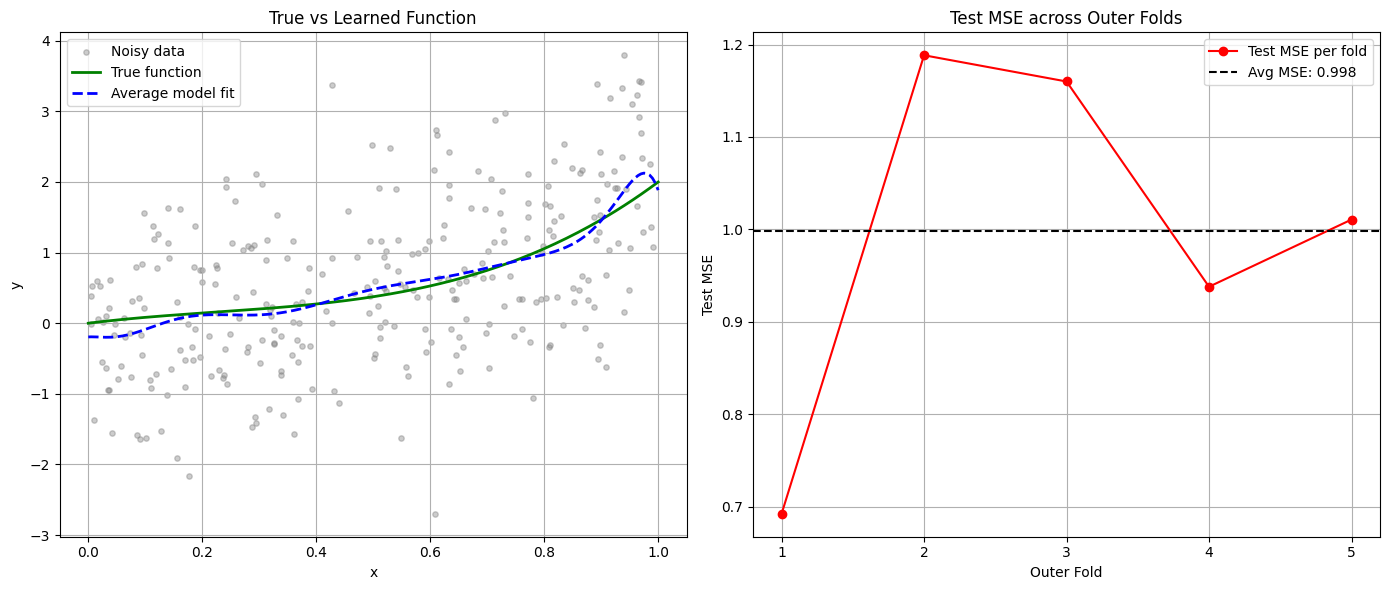


Average Test MSE across folds: 0.9978488900155197
Degrees selected in each fold: [5, 3, 7, 10, 4]


In [3]:
# Step 4-13: Outer loop + inner model selection + final evaluation
for outer_train_index, outer_test_index in outer_cv.split(X):
    X_outer_train, X_outer_test = X[outer_train_index], X[outer_test_index]
    y_outer_train, y_outer_test = y[outer_train_index], y[outer_test_index]

    # Define variable for inner mse for each degree
    inner_mse_per_deg = []

    # Step 5: Loop to evaluate different degrees
    for deg in deg_range:
        inner_mse = []

        # Step 6: Inner loop
        for inner_train_index, inner_val_index in inner_cv.split(X_outer_train):
            X_inner_train = X_outer_train[inner_train_index]
            X_inner_val = X_outer_train[inner_val_index]
            y_inner_train = y_outer_train[inner_train_index]
            y_inner_val = y_outer_train[inner_val_index]

            # Step 7: Create polynomial features
            poly = PolynomialFeatures(degree=deg)
            X_inner_train_poly = poly.fit_transform(X_inner_train)
            X_inner_val_poly = poly.transform(X_inner_val)

            # Step 8: Fit linear regression
            model = LinearRegression()
            model.fit(X_inner_train_poly, y_inner_train)

            # Step 9: Predict
            y_inner_val_pred = model.predict(X_inner_val_poly)

            # Step 10: Calculate MSE
            mse_val = mean_squared_error(y_inner_val, y_inner_val_pred)
            inner_mse.append(mse_val)

        # Step 11: Compute average MSE across inner folds for each degree
        inner_mse_per_deg.append(np.mean(inner_mse))

    # Step 12: Choose best degree using inner CV
    best_deg = list(deg_range)[np.argmin(inner_mse_per_deg)]
    best_degs.append(best_deg)

    # Step 13: Re-train on outer training set with best degree
    poly_final = PolynomialFeatures(degree=best_deg)
    X_outer_train_poly = poly_final.fit_transform(X_outer_train)
    X_outer_test_poly = poly_final.transform(X_outer_test)

    model_final = LinearRegression()
    model_final.fit(X_outer_train_poly, y_outer_train)

    y_outer_test_pred = model_final.predict(X_outer_test_poly)
    test_mse = mean_squared_error(y_outer_test, y_outer_test_pred)
    test_mse_outer.append(test_mse)

    print(f"Best degree = {best_deg}, Test MSE = {test_mse:.4f}")

    # Save fitted curve for final average plot
    Xg_poly = poly_final.transform(X_grid)
    fits_over_folds.append(model_final.predict(Xg_poly))

# True function and average fitted curve
y_true = 3 * X_grid**3 - 2 * X_grid**2 + X_grid
avg_fit = np.mean(fits_over_folds, axis=0)

# Plotting
plt.figure(figsize=(14, 6))

# A) True vs learned function
plt.subplot(1, 2, 1)
plt.scatter(X, y, color='gray', alpha=0.4, s=15, label='Noisy data')
plt.plot(X_grid, y_true, color='green', linewidth=2, label='True function')
plt.plot(X_grid, avg_fit, color='blue', linestyle='--', linewidth=2,
         label='Average model fit')
plt.title("True vs Learned Function")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

# B) MSE on each outer fold
plt.subplot(1, 2, 2)
plt.plot(range(1, len(test_mse_outer) + 1), test_mse_outer, marker='o',
         color='red', label='Test MSE per fold')
plt.axhline(np.mean(test_mse_outer), linestyle='--', color='black',
            label=f'Avg MSE: {np.mean(test_mse_outer):.3f}')
plt.title("Test MSE across Outer Folds")
plt.xlabel("Outer Fold")
plt.ylabel("Test MSE")
plt.xticks(range(1, len(test_mse_outer) + 1))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Final report
print("\nAverage Test MSE across folds:", np.mean(test_mse_outer))
print("Degrees selected in each fold:", best_degs)

